# 산학프로젝트
**제조 공정 품질 불량 예측**

# 08_Unsupervised_Defect_Scoring

- 라벨 없이 검사 우선순위를 매길 수 있는지 확인
- 평가 프로토콜: 07_2와 같은 시간순 walk-forward, 지도학습 비교군은 07_2 저장 확률 재사용
- 주의: 다루는 과제는 불량 탐지이며 공정이상탐지가 아님

## 다루는 질문과 다루지 않는 질문

| | 질문 | 산출물 | 정답 | 이 노트북 |
| --- | --- | --- | --- | --- |
| Q1 | 라벨 없이 검사할 제품을 고를 수 있나 | 제품별 검사 우선순위 | 불량 라벨 (있음) | 다룸 |
| Q2 | 공정 상태가 평소와 달라졌나 | 공정 점검 지시 | 없음 | 다루지 않음 |

**이 노트북은 Q1만 다룸**
- 방법만 비지도이고 과제는 03 ~ 07과 같은 불량 탐지
- 따라서 잣대(불량 라벨)와 프로토콜(07_2 walk-forward)을 지도학습과 동일하게 맞춤

**Q2는 착수하지 않음**
- 불량 라벨을 쓰지 않으며 평가축이 다름 (오경보율 관리, 알려진 공정 변화 검출, 지속성, 기여 변수 지목)
- 평가 설계를 먼저 정해야 함
- 이상 ≠ 불량이며, 구분을 흐리면 Q1 결과로 Q2를 판단하게 됨

## import

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=='data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 경로설정

In [2]:
if Path.cwd().name!='data':
    os.chdir('data')

## 데이터 전처리

- 03 ~ 07과 같은 순서로 구성
- 인덱스를 유지해야 07_2가 저장한 확률과 행 정렬 가능

In [3]:
# 02_EDA에서 저장한 전처리 데이터
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

# 분할 기준으로만 쓰는 생산시각
time_stamp=pd.to_datetime(model_data['TimeStamp'])

# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

final_df=model_data.drop(columns=drop_columns)

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']
part_label=X_part['Part'].copy()

X_part=pd.get_dummies(data=X_part, columns=['Part'], drop_first=True, dtype=int)
print(f'전체: {X_part.shape}, 불량 수: {Y.sum()}, 기저 불량률 {Y.mean():.4%}')

전체: (5230, 26), 불량 수: 60, 기저 불량률 1.1472%


## 1. 시간순 정렬과 에피소드

- 07_1 · 07_2와 같은 기준(불량 간격 4시간 초과)으로 에피소드 구분

In [4]:
sort_index=time_stamp.sort_values(kind='mergesort').index

X_sorted=X_part.loc[sort_index]
Y_sorted=Y.loc[sort_index]
time_sorted=time_stamp.loc[sort_index]

EPISODE_GAP_HOURS=4
defect_time=time_sorted[Y_sorted==1]
episode_id=pd.Series(-1, index=sort_index, dtype=int)
episode_id.loc[defect_time.index]=(defect_time.diff()>pd.Timedelta(hours=EPISODE_GAP_HOURS)).cumsum().to_numpy()

print(f'생산일 {time_sorted.dt.date.nunique()}일, 에피소드 {episode_id[episode_id>=0].nunique()}개')


def score_anomaly(score, label, y=None, episode=None, ratio=0.10):
    """이상점수(클수록 이상)를 불량 라벨로 평가합니다."""
    y=Y_sorted if y is None else y
    episode=episode_id if episode is None else episode
    mask=score.notna()
    y_eval, s_eval=y[mask], score[mask]
    k=int(round(len(y_eval)*ratio))
    cut=np.sort(s_eval.to_numpy())[::-1][k-1]
    selected=s_eval>=cut
    episode_eval=episode[mask]
    hits=sum(bool(selected[episode_eval==e].any()) for e in sorted(episode_eval[episode_eval>=0].unique()))
    n_episode=episode_eval[episode_eval>=0].nunique()
    ap=average_precision_score(y_eval, s_eval)
    return {
        '방법': label,
        '평가 행': int(mask.sum()),
        '평가 불량': int(y_eval.sum()),
        'AP': round(ap, 4),
        'AP 기저 대비': round(ap/y_eval.mean(), 1),
        'ROC AUC': round(roc_auc_score(y_eval, s_eval), 3),
        'Recall@10%': round(((selected) & (y_eval==1)).sum()/y_eval.sum(), 3),
        '에피소드 감지': f'{hits}/{n_episode}',
    }

생산일 13일, 에피소드 6개


## 2. 전체 적합 기준 이상점수 (참고용)

- 라벨은 쓰지 않으나 평가할 행에까지 적합시킨 값이라 낙관됨
- 판단 근거로 쓰지 않으며 3절과의 차이를 보기 위해 기재

In [5]:
scaler_all=StandardScaler().fit(X_sorted)
X_scaled=scaler_all.transform(X_sorted)

transductive_rows=[]

# Isolation Forest
iso_all=IsolationForest(n_estimators=300, random_state=0, n_jobs=-1).fit(X_scaled)
transductive_rows.append(score_anomaly(pd.Series(-iso_all.score_samples(X_scaled), index=sort_index),
                                       'IsolationForest'))

# Local Outlier Factor
lof_all=LocalOutlierFactor(n_neighbors=20)
lof_all.fit_predict(X_scaled)
transductive_rows.append(score_anomaly(pd.Series(-lof_all.negative_outlier_factor_, index=sort_index),
                                       'LocalOutlierFactor (k=20)'))

# 로버스트 마할라노비스 거리
mcd_all=MinCovDet(random_state=0).fit(X_scaled)
transductive_rows.append(score_anomaly(pd.Series(mcd_all.mahalanobis(X_scaled), index=sort_index),
                                       'Mahalanobis (MCD)'))

# PCA 복원 오차
for n_components in [5, 10, 15]:
    pca_all=PCA(n_components=n_components, random_state=0).fit(X_scaled)
    recon=pca_all.inverse_transform(pca_all.transform(X_scaled))
    transductive_rows.append(score_anomaly(pd.Series(np.mean((X_scaled-recon)**2, axis=1), index=sort_index),
                                           f'PCA 복원 오차 (n={n_components})'))

transductive_df=pd.DataFrame(transductive_rows)
transductive_df

,방법,평가 행,평가 불량,AP,AP 기저 대비,ROC AUC,Recall@10%,에피소드 감지
0,IsolationForest,5230,60,0.0652,5.7,0.871,0.500,5/6
1,LocalOutlierFactor (k=20),5230,60,0.1126,9.8,0.623,0.267,3/6
2,Mahalanobis (MCD),5230,60,0.0304,2.7,0.805,0.217,3/6
3,PCA 복원 오차 (n=5),5230,60,0.0828,7.2,0.506,0.150,2/6
4,PCA 복원 오차 (n=10),5230,60,0.1457,12.7,0.726,0.433,4/6
5,PCA 복원 오차 (n=15),5230,60,0.1444,12.6,0.723,0.433,5/6


## 3. Walk-forward 조건 비교 (판단 근거)

- 07_2와 같은 방식으로 각 블록을 직전까지의 행으로만 적합한 이상탐지기로 점수화
- 라벨을 쓰지 않으므로 학습 불량 2건 조건 불필요, 행 수 300건만 확보되면 시작
- 지도학습 비교군은 07_2가 저장한 확률을 그대로 사용

In [6]:
MIN_TRAIN_ROWS=300


def walk_forward_anomaly(block_size, kind, n_components=10):
    block_ids=np.arange(len(X_sorted))//block_size
    score=pd.Series(np.nan, index=sort_index)
    n_fit=0
    for block in np.unique(block_ids):
        test_pos=np.where(block_ids==block)[0]
        train_pos=np.arange(test_pos[0])
        if len(train_pos)<MIN_TRAIN_ROWS:
            continue
        scaler=StandardScaler().fit(X_sorted.iloc[train_pos])
        train_scaled=scaler.transform(X_sorted.iloc[train_pos])
        test_scaled=scaler.transform(X_sorted.iloc[test_pos])
        if kind=='pca':
            model=PCA(n_components=n_components, random_state=0).fit(train_scaled)
            recon=model.inverse_transform(model.transform(test_scaled))
            score.iloc[test_pos]=np.mean((test_scaled-recon)**2, axis=1)
        else:
            model=IsolationForest(n_estimators=300, random_state=0, n_jobs=-1).fit(train_scaled)
            score.iloc[test_pos]=-model.score_samples(test_scaled)
        n_fit+=1
    return score, n_fit


anomaly_score={}
for block_size in [50, 100]:
    for kind, n_components in [('iso', None), ('pca', 10), ('pca', 15)]:
        name=f"{'IsolationForest' if kind=='iso' else f'PCA 복원 오차 (n={n_components})'} / {block_size}샷"
        start=time.time()
        anomaly_score[name], n_fit=walk_forward_anomaly(block_size, kind, n_components or 10)
        print(f'{name}: {n_fit}회 적합, {time.time()-start:.0f}초')

IsolationForest / 50샷: 99회 적합, 41초


PCA 복원 오차 (n=10) / 50샷: 99회 적합, 1초


PCA 복원 오차 (n=15) / 50샷: 99회 적합, 1초


IsolationForest / 100샷: 50회 적합, 21초


PCA 복원 오차 (n=10) / 100샷: 50회 적합, 0초


PCA 복원 오차 (n=15) / 100샷: 50회 적합, 0초


In [7]:
# 07_2 지도학습 walk-forward 확률 (같은 인덱스로 정렬)
supervised=pd.read_csv('07_2_WalkForward_proba.csv', index_col=0)
supervised.index=supervised.index.astype(X_part.index.dtype)

compare_frame=pd.DataFrame(anomaly_score)
for block_size in [50, 100]:
    compare_frame[f'[지도] RandomForest / {block_size}샷']=supervised[f'{block_size}샷'].reindex(sort_index)

# 모든 방법이 공통으로 점수를 낸 행만 남긴다
common_mask=compare_frame.notna().all(axis=1)
print(f'공통 평가 행 {common_mask.sum()}건, 불량 {int(Y_sorted[common_mask].sum())}건, '
      f'에피소드 {episode_id[common_mask][episode_id[common_mask]>=0].nunique()}개')

walkforward_df=pd.DataFrame([score_anomaly(compare_frame[column].where(common_mask), column)
                             for column in compare_frame.columns])
walkforward_df.sort_values('AP', ascending=False)

공통 평가 행 4930건, 불량 43건, 에피소드 5개


,방법,평가 행,평가 불량,AP,AP 기저 대비,ROC AUC,Recall@10%,에피소드 감지
6,[지도] RandomForest / 50샷,4930,43,0.0714,8.2,0.865,0.605,4/5
0,IsolationForest / 50샷,4930,43,0.0359,4.1,0.862,0.535,4/5
3,IsolationForest / 100샷,4930,43,0.0344,3.9,0.856,0.512,4/5
7,[지도] RandomForest / 100샷,4930,43,0.0313,3.6,0.817,0.488,4/5
2,PCA 복원 오차 (n=15) / 50샷,4930,43,0.0141,1.6,0.572,0.140,1/5
5,PCA 복원 오차 (n=15) / 100샷,4930,43,0.0135,1.6,0.580,0.186,1/5
1,PCA 복원 오차 (n=10) / 50샷,4930,43,0.0121,1.4,0.594,0.140,1/5
4,PCA 복원 오차 (n=10) / 100샷,4930,43,0.0117,1.3,0.600,0.140,1/5


### 전체 적합과 walk-forward의 차이

- 같은 방법에서 프로토콜만 바꾼 값을 나란히 배치
- 이상탐지도 지도학습과 같이 프로토콜에 민감

In [8]:
protocol_gap=[]
for label, transductive_name, wf_name in [
    ('IsolationForest', 'IsolationForest', 'IsolationForest / 50샷'),
    ('PCA 복원 오차 (n=10)', 'PCA 복원 오차 (n=10)', 'PCA 복원 오차 (n=10) / 50샷'),
    ('PCA 복원 오차 (n=15)', 'PCA 복원 오차 (n=15)', 'PCA 복원 오차 (n=15) / 50샷'),
]:
    a=transductive_df[transductive_df['방법']==transductive_name].iloc[0]
    b=walkforward_df[walkforward_df['방법']==wf_name].iloc[0]
    protocol_gap.append({'방법': label, '전체 적합 AP': a['AP'], 'walk-forward AP': b['AP'],
                         '전체 적합 R@10%': a['Recall@10%'], 'walk-forward R@10%': b['Recall@10%']})

pd.DataFrame(protocol_gap)

,방법,전체 적합 AP,walk-forward AP,전체 적합 R@10%,walk-forward R@10%
0,IsolationForest,0.0652,0.0359,0.500,0.535
1,PCA 복원 오차 (n=10),0.1457,0.0121,0.433,0.140
2,PCA 복원 오차 (n=15),0.1444,0.0141,0.433,0.140


## 4. unlabeled 정상 데이터로 학습한 이상탐지

- 라벨이 필요 없으므로 unlabeled를 학습에 쓸 수 있는지 확인
- 가능하면 표본 제약이 사라짐
- `ERR_FACT_QTY`가 0인 lot만 정상으로 보고 labeled와 같은 품명 4종으로 제한
- 센서 결측(0으로 기록된 행) 제외

In [9]:
# 02_EDA에서 같은 규칙으로 저장한 unlabeled
unlabeled=pd.read_csv('unlabeled_modeling.csv', index_col=0)

# labeled와 같은 품명 4종, 무불량 lot만
unlabeled=unlabeled[unlabeled['Part'].isin(part_label.unique())]
unlabeled=unlabeled[unlabeled['ERR_FACT_QTY']==0]

X_unlabeled=pd.get_dummies(unlabeled, columns=['Part'], drop_first=True, dtype=int)
X_unlabeled=X_unlabeled.reindex(columns=X_part.columns)

# 센서 결측 행 제외
sensor_cols=['Max_Screw_RPM', 'Average_Screw_RPM', 'Average_Back_Pressure',
             'Barrel_Temperature_1', 'Mold_Temperature_3', 'Mold_Temperature_4']
X_unlabeled_all=X_unlabeled.dropna()
X_unlabeled=X_unlabeled_all[~(X_unlabeled_all[sensor_cols]==0).any(axis=1)]
print(f'unlabeled 학습 데이터 {len(X_unlabeled)}행 (labeled 전체 {len(X_part)}행)')

scaler_unlabeled=StandardScaler().fit(X_unlabeled)
train_scaled=scaler_unlabeled.transform(X_unlabeled)
eval_scaled=scaler_unlabeled.transform(X_sorted)

unlabeled_rows=[]
pca_unlabeled=PCA(n_components=10, random_state=0).fit(train_scaled)
recon=pca_unlabeled.inverse_transform(pca_unlabeled.transform(eval_scaled))
unlabeled_rows.append(score_anomaly(pd.Series(np.mean((eval_scaled-recon)**2, axis=1), index=sort_index),
                                    'PCA 복원 오차 (n=10) / unlabeled 학습'))

iso_unlabeled=IsolationForest(n_estimators=300, random_state=0, n_jobs=-1).fit(train_scaled)
unlabeled_rows.append(score_anomaly(pd.Series(-iso_unlabeled.score_samples(eval_scaled), index=sort_index),
                                    'IsolationForest / unlabeled 학습'))

pd.DataFrame(unlabeled_rows)

unlabeled 학습 데이터 6276행 (labeled 전체 5230행)


,방법,평가 행,평가 불량,AP,AP 기저 대비,ROC AUC,Recall@10%,에피소드 감지
0,PCA 복원 오차 (n=10) / unlabeled 학습,5230,60,0.0376,3.3,0.485,0.20,2/6
1,IsolationForest / unlabeled 학습,5230,60,0.0294,2.6,0.443,0.15,1/6


### 두 집단을 구분할 수 있는지

- unlabeled를 정상 데이터로 쓰려면 labeled와 **같은 공정의 정상 상태**여야 함
- 분류기가 두 집단을 잘 구분하면 같은 정상 상태가 아니라 **다른 운전 조건**이라는 뜻
- labeled 양품과 위 학습 데이터를 5-fold로 구분해 ROC AUC 확인
- 센서 결측 행을 포함한 집합도 함께 봐서, 구분이 결측 탓인지 운전 조건 탓인지 분리

In [10]:
X_normal=X_sorted[Y_sorted==0]

domain_rows=[]
for label, unlabeled_set in [('센서 결측 제외 (위 학습 데이터)', X_unlabeled),
                             ('센서 결측 포함', X_unlabeled_all)]:
    X_domain=pd.concat([X_normal, unlabeled_set], ignore_index=True)
    y_domain=np.r_[np.zeros(len(X_normal), dtype=int), np.ones(len(unlabeled_set), dtype=int)]

    proba=cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
                            X_domain, y_domain,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
                            method='predict_proba')[:, 1]

    domain_rows.append({'unlabeled 조건': label,
                        'labeled 양품': len(X_normal),
                        'unlabeled': len(unlabeled_set),
                        'ROC AUC': round(roc_auc_score(y_domain, proba), 4)})

print('두 집단을 구분하는 분류기 (구분될수록 다른 도메인)')
display(pd.DataFrame(domain_rows))

# 무엇이 두 집단을 가르는지
domain_clf=RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1).fit(
    pd.concat([X_normal, X_unlabeled], ignore_index=True),
    np.r_[np.zeros(len(X_normal), dtype=int), np.ones(len(X_unlabeled), dtype=int)])

print()
print('상위 기여 변수')
pd.Series(domain_clf.feature_importances_, index=X_part.columns).sort_values(ascending=False).head(8).round(4)

두 집단을 구분하는 분류기 (구분될수록 다른 도메인)


,unlabeled 조건,labeled 양품,unlabeled,ROC AUC
0,센서 결측 제외 (위 학습 데이터),5170,6276,0.9863
1,센서 결측 포함,5170,10391,0.9919



상위 기여 변수


Mold_Temperature_4       0.1094
Average_Screw_RPM        0.1036
Mold_Temperature_3       0.0903
Average_Back_Pressure    0.0824
Plasticizing_Time        0.0823
Plasticizing_Position    0.0724
Cycle_Time               0.0612
Cushion_Position         0.0515
dtype: float64

### 해석

**전이되지 않음**
- labeled 안에서 walk-forward로 학습한 IsolationForest보다 낮음
- ROC AUC가 0.5 아래라 unlabeled 기준 이상점수와 labeled 불량은 무관

**원인은 도메인 차이**
- 두 집단을 구분하는 분류기의 ROC AUC **0.9863**. 센서 결측 행을 포함해도 0.9919로 거의 같으므로, 결측이 아니라 운전 조건 자체가 다름
- 가르는 변수도 금형온도 · 스크류 속도 · 계량 계열이라 설정값이 다름
- 기간도 unlabeled 2020-03 ~ 10, labeled 2020-10 ~ 11로 거의 겹치지 않음
- 오토인코더 정상 데이터 확장을 접은 것과 같은 이유 (`ANALYSIS_FLOW.md` 12절)

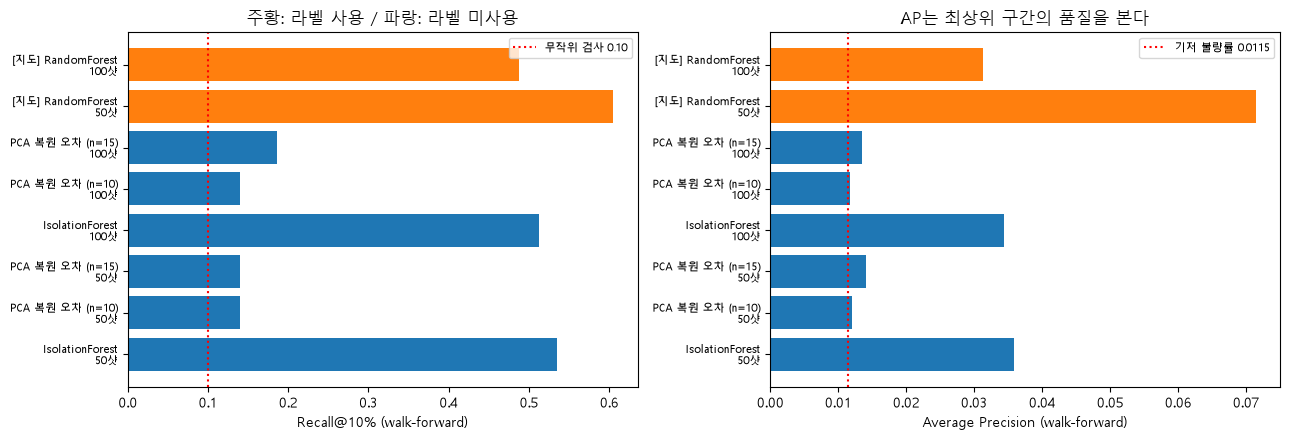

In [11]:
plot_df=walkforward_df.set_index('방법').loc[compare_frame.columns]
colors=['tab:orange' if '지도' in name else 'tab:blue' for name in plot_df.index]

fig, axes=plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(range(len(plot_df)), plot_df['Recall@10%'], color=colors)
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels([name.replace(' / ', '\n') for name in plot_df.index], fontsize=8)
axes[0].axvline(0.10, color='red', linestyle=':', label='무작위 검사 0.10')
axes[0].set_xlabel('Recall@10% (walk-forward)')
axes[0].set_title('주황: 라벨 사용 / 파랑: 라벨 미사용')
axes[0].legend(fontsize=8)

axes[1].barh(range(len(plot_df)), plot_df['AP'], color=colors)
axes[1].set_yticks(range(len(plot_df)))
axes[1].set_yticklabels([name.replace(' / ', '\n') for name in plot_df.index], fontsize=8)
axes[1].axvline(Y_sorted.mean(), color='red', linestyle=':', label='기저 불량률 0.0115')
axes[1].set_xlabel('Average Precision (walk-forward)')
axes[1].set_title('AP는 최상위 구간의 품질을 본다')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. 정리

**최종 모델 변경 없음**
- 라벨이 있으면 라벨을 쓰는 편이 나음
- 이 노트북은 확인용이며 채택 후보를 만들지 않음

**IsolationForest는 라벨 없이 지도학습 100샷 재학습을 앞섬**
- AP 0.0359 vs 0.0313, 에피소드 감지는 4/5로 동일
- 지도학습 50샷(AP 0.0714)에는 못 미침
- ROC AUC는 지도학습과 사실상 동일(0.862 vs 0.865)한데 AP만 절반
- 불량을 전반적으로 위쪽에 세우나 최상위 구간은 채우지 못한다는 뜻
- 검사 물량이 넉넉하면 격차가 작고 물량을 조일수록 지도학습이 유리

**PCA 복원 오차는 프로토콜에 따라 순위가 뒤바뀜**
- 전체 적합 AP 0.1457로 1위, walk-forward 0.0121로 꼴찌
- 프로토콜을 맞추지 않았다면 잘못된 결론을 낼 뻔함
- 04_6 → 07_2의 교훈이 비지도 계열에서 재현됨

**unlabeled 학습은 전이 실패**
- Q1에 대한 결론이며 Q2를 부정하지 않음

**남는 용도**
- 학습 데이터가 없는 설비(S06) 콜드스타트
- 단, 대시보드 범위 확대에 해당하므로 별도 판단 필요

In [12]:
transductive_df.to_csv('08_Unsupervised_Defect_Scoring_transductive.csv', index=False, encoding='utf-8-sig')
walkforward_df.to_csv('08_Unsupervised_Defect_Scoring_walkforward.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(unlabeled_rows).to_csv('08_Unsupervised_Defect_Scoring_unlabeled.csv', index=False, encoding='utf-8-sig')
print('저장 완료')

저장 완료
